In [1]:
# !pip install ipywidgets jax jaxlib

# https://notebook.community/DAInamite/programming-humanoid-robot-in-python/kinematics/inverse_kinematics_2d_jax

%matplotlib notebook
from matplotlib import pylab as plt
from numpy import random, pi
from __future__ import division
from IPython import display
from ipywidgets import interact, fixed

import jax.numpy as np
from jax import grad, jit

import time

import numpy

In [2]:
def trans(x, y, a):
    '''create a 2D transformation'''
    s = np.sin(a)
    c = np.cos(a)
    return np.asarray([[c, -s, x],
                       [s,  c, y],
                       [0,  0, 1]])

def from_trans(m):
    '''get x, y, theta from transform matrix'''
    a = np.arctan2(m[1, 0], m[0, 0])
    return np.asarray([m[0, -1], m[1, -1], a])

In [3]:
def forward_kinematics(T0, l, a):

    # T0: [[ 1. -0.  0.]
    #      [ 0.  1.  0.]
    #      [ 0.  0.  1.]]
    # l: [0, 3, 2, 1, 1]
    # a: [0.43772719 0.42353153 0.47140152 0.20316388]
    
    T = [T0]
    for i in range(len(a)):
        Ti = np.dot(T[-1], trans(l[i], 0, a[i]))
        T.append(Ti)
    Te = np.dot(T[-1], trans(l[-1], 0, 0))  # end effector
    T.append(Te)
    return T


In [4]:
%matplotlib widget

import matplotlib.pyplot as plt

def show_robot_arm(T):
    xs = [Ti[0,-1] for Ti in T]
    ys = [Ti[1,-1] for Ti in T]
    zs = np.zeros(5)

    fig = plt.figure(figsize=(8,8))
    ax = plt.axes(projection = '3d')
    ax.plot3D(xs, ys, zs, 'green')
    
    x_min = np.array(xs).min()
    x_max = np.array(xs).max()
    y_min = np.array(ys).min()
    y_max = np.array(ys).max()
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max]) 

    # creating the plot
    plot_geeks = ax.plot(xs, ys, zs, '-or', linewidth=5, markersize=10)
    
    # setting title and labels
    ax.set_title("3D plot")
    ax.set_xlabel('x-axis')
    ax.set_ylabel('y-axis')
    ax.set_zlabel('z-axis')
    
    ax.view_init(90, 0)

    # displaying the plot
    plt.show()


In [5]:

l = [0, 3, 2, 1]
#l = [0, 3, 2, 1, 1]
#l = [0, 3, 2, 1, 1, 1]
#l = [1] * 30
N = len(l) - 1  # number of links
max_len = sum(l)
a = random.random_sample(N)  # angles of joints
T0 = trans(0, 0, 0)  # base


In [6]:
def error_func(theta, target):
    Ts = forward_kinematics(T0, l, theta)
    Te = Ts[-1]
    e = target - Te
    return np.sum(e * e)

theta = random.random(N)
def inverse_kinematics(x_e, y_e, theta_e, theta):
    target = trans(x_e, y_e, theta_e)
    func = lambda t: error_func(t, target)
    func_grad = jit(grad(func))
    
    for i in range(1000):
        e = func(theta)
        d = func_grad(theta)
        theta -= d * 1e-2
        if e < 1e-4:
            break
    
    return theta

T = forward_kinematics(T0, l, theta)
# show_robot_arm(T)
Te = np.asarray([from_trans(T[-1])])

@interact(x_e=(0, max_len, 0.01), y_e=(-max_len, max_len, 0.01), theta_e=(-pi, pi, 0.01), theta=fixed(theta))
def set_end_effector(x_e=Te[0,0], y_e=Te[0,1], theta_e=Te[0,2], theta=theta):
    
    print("x_e: ", x_e)
    print("y_e: ", y_e)
    print("theta_e: ", theta_e)
    print("theta: ", theta)
    print("T0: ", T0)
    print("l: ", l)
    
    theta = inverse_kinematics(x_e, y_e, theta_e, theta)
    T = forward_kinematics(T0, l, theta)
    show_robot_arm(T)
    return theta

interactive(children=(FloatSlider(value=4.925394058227539, description='x_e', max=6.0, step=0.01), FloatSlider…

<IPython.core.display.Javascript object>


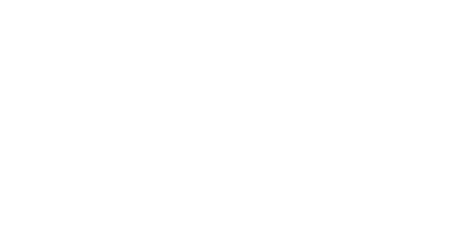

rand:  0.30916053090175244 0.4739102826218262
i:  0
i:  0
i:  1
i:  2
i:  3
i:  4
i:  5
i:  6
i:  7
i:  8
i:  9
i:  10
i:  11
i:  12
i:  13
i:  14
i:  15
i:  16
i:  17
i:  18
i:  19
i:  20
i:  21
i:  22
i:  23
i:  24
i:  25
i:  26
i:  27
i:  28
i:  29


In [35]:
from matplotlib import animation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"  # for matplotlib 2.1 and above, uses JavaScript

# l = [0, 3, 2, 1]
joint_list = [0, 3, 2, 1, 1]
#l = [0, 3, 2, 1, 1, 1]
#l = [1] * 30
N = len(joint_list) - 1  # number of links
max_len = sum(joint_list)

angles = random.random_sample(N)  # angles of joints

T0 = trans(0, 0, 0)  # base
frame_num = 30

T = forward_kinematics(T0, joint_list, theta)

xs = [Ti[0,-1] for Ti in T]
ys = [Ti[1,-1] for Ti in T]

# fig, ax = plt.subplots(1)
fig = plt.figure(1)
ax = plt.axes()
plots = ax.plot(xs, ys, '-or', linewidth=5, markersize=10)
x_min = np.array(xs).min() - 4.0
x_max = np.array(xs).max() + 4.0
y_min = np.array(ys).min() - 4.0
y_max = np.array(ys).max() + 4.0
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')

Xf = from_trans(T[N])[0]
Yf = from_trans(T[N])[1]

X_rand = numpy.random.random()
Y_rand = numpy.random.random()
print("rand: ", X_rand, Y_rand)

X_dest = (x_max - x_min) * X_rand + x_min
Y_dest = (y_max - y_min) * Y_rand + y_min

x_interp = numpy.linspace(Xf, X_dest, frame_num)
y_interp = numpy.linspace(Yf, Y_dest, frame_num)


def trans_a(x, y, angle):
    '''create a 2D transformation'''
    
    s = numpy.sin(angle)
    c = numpy.cos(angle)
    
    return numpy.asarray([[c, -s, x],
                          [s,  c, y],
                          [0,  0, 1]])

def from_trans_a(m):
    '''get x, y, theta from transform matrix'''

    a = np.arctan2(m[1, 0], m[0, 0])
    return np.asarray([m[0, -1], m[1, -1], a])

def forward_kinematics_a(T0, joint_list, angles):
    T = [T0]
    for i in range(len(angles)):
        Ti = np.dot(T[-1], trans_a(joint_list[i], 0, angles[i]))
        T.append(Ti)
    Te = np.dot(T[-1], trans_a(joint_list[-1], 0, 0))  # end effector
    T.append(Te)
    return T

def error_func_a(angles, target):
    Ts = forward_kinematics_a(T0, joint_list, angles)
    Te = Ts[-1]
    e = target - Te
    return np.sum(e * e)

def inverse_kinematics_a(x_e, y_e, theta_e, theta):
    target = trans(x_e, y_e, theta_e)
    func = lambda t: error_func(t, target)
    func_grad = jit(grad(func))
    
    loop_time = time.time()
    for i in range(1000):
        e = func(theta)
        d = func_grad(theta)
        theta -= d * 1e-2
        if e < 1e-4:
            break
#     print("loop time: ", time.time() - loop_time)
    
    return theta

def animate(i):
#     print("i: ", i)

    theta_e = 0.0
    
    angles_new = inverse_kinematics_a(x_interp[i], y_interp[i], theta_e, angles)
    T = forward_kinematics(T0, joint_list, angles_new)
    
    xs = [Ti[0,-1] for Ti in T]
    ys = [Ti[1,-1] for Ti in T]
    
    plots[0].set_data(xs, ys)
    

ani = animation.FuncAnimation(fig, animate, frames=frame_num)
plt.close()
ani


In [ ]:

# TODO:
# create potential/distance field
#   give the potential field a gradient
#   with a preferred direction of approach
# make the error function the distance to the goal
# make the error function for the intermediate joints 
#   such that they want to minimize the gradient to the goal
# animate moving the arm


In [ ]:

# distance field, gradient converges on point

plt.plot(timestamps[start:stop], average_height_weighted[start:stop], 'b')
plt.show()


